# <p style="text-align:center"><span style="color:orange;font-family:'Comic Sans MS'">ML Visant l'analyse des sons populaires sur Spotify 🎵</span></p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
pd.set_option('display.max_columns', None)

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score



def objective(trial):
    n_estimators = trial.suggest_int("n_estimators",50,300)
    max_depth = trial.suggest_int("max_depth",3,20)
    min_samples_split = trial.suggest_int("min_samples_split",2,10)

    model = RandomForestRegressor(n_estimators=n_estimators,
                                   max_depth= max_depth,
                                   min_samples_split=min_samples_split,
                                   random_state=42)
    mse = -cross_val_score(model,X_train,y_train,cv=5,scoring="neg_mean_squared_error").mean()
    return mse

In [3]:
data = pd.read_csv("D:/Datasets/ML/Popular_Spotify_Songs.csv")
data.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6


#  **Signification des variables**  
<style>
  h1, h2, h3 { text-align:center;font-family: 'Comic Sans MS', cursive; color: orange; text-shadow: 2px 2px #00bfffff; }
  th { text-align:center;background: #ffeb3b; color: #d8791bff; font-weight: bold; }
  
  table{
    width:100% !important;
    max-width: 1200px;
    margin: 0 auto;
    border-collapse: collapse;
    font-family:'Comic Sans MS',cursive, sans-serif;
    font-size:16px;
  }

  th,td{
    padding:12px 16px !important;
    text-align:center !important;
  }
</style>

---

| **🎤 Variable** | **📊 Type** | **💬 Description** | **✨ Exemple** |
|------------------|------------|---------------------|----------------|
| `track_name` | `object` | **Nom du morceau** | `Blinding Lights` |
| `artist(s)_name` | `object` | **Artiste(s)** | `The Weeknd` |
| `artist_count` | `int64` | **Nb d'artistes** | `1` |
| `released_year` | `int64` | **Année de sortie** | `2020` |
| `released_month` | `int64` | **Mois (1–12)** | `3` |
| `released_day` | `int64` | **Jour du mois** | `14` |
| `in_spotify_playlists` | `int64` | **Playlists Spotify** | `12 456` |
| `in_spotify_charts` | `int64` | **Classement Spotify** | `89` |
| `streams` | `int64` | **🔥 Streams totaux** | `2 345 678 901` |
| `in_apple_playlists` | `int64` | **Playlists Apple** | `567` |
| `in_apple_charts` | `int64` | **Classement Apple** | `45` |
| `in_deezer_playlists` | `int64` | **Playlists Deezer** | `234` |
| `in_deezer_charts` | `int64` | **Classement Deezer** | `12` |
| `in_shazam_charts` | `float64` | **Classement Shazam** | `3.0` |
| `bpm` | `int64` | **Tempo (battements/min)** | `128` |
| `key` | `object` | **Tonalité** | `F` |
| `mode` | `object` | **Majeur / Mineur** | `Major` |
| `danceability_%` | `int64` | **💃 Dansabilité** | `75%` |
| `valence_%` | `int64` | **😊 Positivité** | `60%` |
| `energy_%` | `int64` | **⚡ Énergie** | `80%` |
| `acousticness_%` | `int64` | **🎻 Acoustique** | `15%` |
| `instrumentalness_%` | `int64` | **🎺 Instrumental** | `0%` |
| `liveness_%` | `int64` | **🎤 Live vibe** | `25%` |
| `speechiness_%` | `int64` | **🗣 Paroles parlées** | `5%` |

---

> **🎯 Variables stars** :  
> `streams` • `danceability_%` • `energy_%` • `valence_%` • `in_spotify_playlists`

<span class="note">*Parfait pour prédire les hits et danser en analysant !*</span>

---


In [4]:
data.shape

(953, 24)

In [5]:
data.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [6]:
data.isna().sum() 

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

In [7]:
data["in_shazam_charts"] = pd.to_numeric(data["in_shazam_charts"],errors='coerce')
data["in_shazam_charts"] = data["in_shazam_charts"].fillna(data["in_shazam_charts"].mean())

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le1 = LabelEncoder()

data["mode"] = le1.fit_transform(data["mode"])

In [9]:
non_null = data["key"].dropna()

In [10]:
non_null = le.fit_transform(non_null)

In [11]:
data.loc[data["key"].notna(),"key_"] = non_null

In [12]:
 
data["key_"] = pd.to_numeric(data["key_"],errors='coerce')
data["key_"] = data["key_"].fillna(data["key_"].mean())

In [13]:
data.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,key_
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826.0,125,B,0,80,89,83,31,0,8,4,2.0
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382.0,92,C#,0,71,61,74,7,0,10,4,3.0
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949.0,138,F,0,51,32,53,17,0,31,6,7.0
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548.0,170,A,0,55,58,72,11,0,11,15,0.0
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425.0,144,A,1,65,23,80,14,63,11,6,0.0


In [14]:
data = data.drop(columns=["artist_count","track_name","artist(s)_name","released_year","released_month","released_day","key"],axis=1)

In [15]:
data.head()

,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,key_
0,553,147,141381703,43,263,45,10,826.0,125,0,80,89,83,31,0,8,4,2.0
1,1474,48,133716286,48,126,58,14,382.0,92,0,71,61,74,7,0,10,4,3.0
2,1397,113,140003974,94,207,91,14,949.0,138,0,51,32,53,17,0,31,6,7.0
3,7858,100,800840817,116,207,125,12,548.0,170,0,55,58,72,11,0,11,15,0.0
4,3133,50,303236322,84,133,87,15,425.0,144,1,65,23,80,14,63,11,6,0.0


In [16]:
data = data.drop(574)

In [17]:
for col in data.columns:
    if data[col].dtype == object:
        data[col] = data[col].str.replace(",","").astype(float)
    

In [18]:
data["Spotify_Pop_charts"] = 100/(0.8*data["in_spotify_charts"] + 0.05*data["in_apple_charts"] + 0.05*data["in_deezer_charts"] + 0.1*data["in_shazam_charts"]+1e6).astype('float64')
data["Spotify_Pop_Playlists"] = 100/(0.8*data["in_spotify_playlists"] + 0.1*data["in_apple_playlists"] + 0.1*data["in_deezer_playlists"]+1e6).astype('float64')

In [19]:
data.head()

,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,key_,Spotify_Pop_charts,Spotify_Pop_Playlists
0,553,147,141381703.0,43,263,45.0,10,826.0,125,0,80,89,83,31,0,8,4,2.0,0.0001,0.000100
1,1474,48,133716286.0,48,126,58.0,14,382.0,92,0,71,61,74,7,0,10,4,3.0,0.0001,0.000100
2,1397,113,140003974.0,94,207,91.0,14,949.0,138,0,51,32,53,17,0,31,6,7.0,0.0001,0.000100
3,7858,100,800840817.0,116,207,125.0,12,548.0,170,0,55,58,72,11,0,11,15,0.0,0.0001,0.000099
4,3133,50,303236322.0,84,133,87.0,15,425.0,144,1,65,23,80,14,63,11,6,0.0,0.0001,0.000100


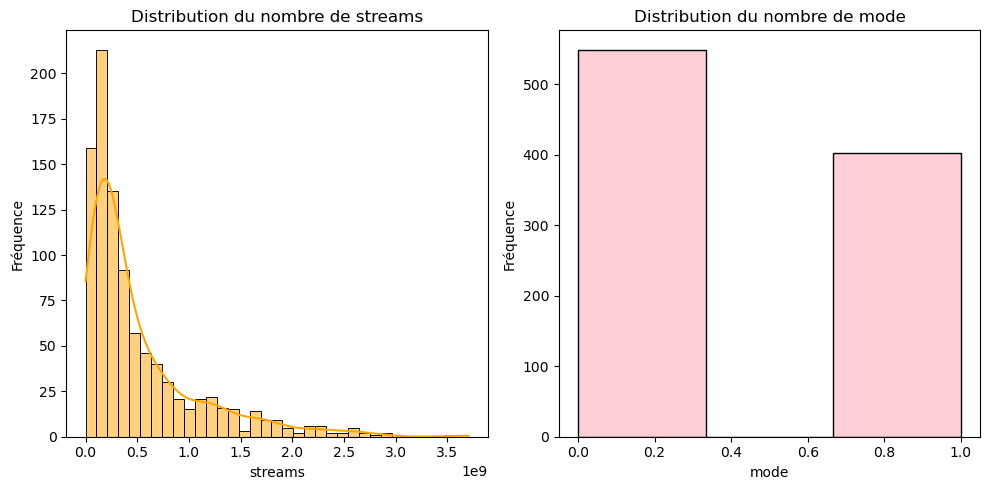

In [20]:
import seaborn as sns

fig,axes = plt.subplots(1,2,figsize=(10,5))

sns.histplot(data["streams"],kde=True,color="orange",ax = axes[0])
axes[0].set_title("Distribution du nombre de streams")
axes[0].set_xlabel('streams')
axes[0].set_ylabel('Fréquence')

sns.histplot(data["mode"],bins = 3,ax = axes[1],color="pink")
axes[1].set_title("Distribution du nombre de mode")
axes[1].set_xlabel('mode')
axes[1].set_ylabel('Fréquence')
plt.tight_layout()
plt.show()

In [21]:
y = data["streams"]
X = (data.drop(columns=["streams"]))

In [22]:
from sklearn.preprocessing import StandardScaler
sd = StandardScaler()

#X = sd.fit_transform(X)

In [23]:
X.describe()

,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,key_,Spotify_Pop_charts,Spotify_Pop_Playlists
count,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,9.520000e+02,9.520000e+02
mean,5202.565126,12.022059,67.866597,51.963235,385.535714,2.669118,51.230096,122.553571,0.423319,66.984244,51.406513,64.274160,27.078782,1.582983,18.214286,10.138655,5.158093,9.999825e-05,9.958502e-05
std,7901.400683,19.582405,86.470591,50.628850,1131.078760,6.038152,122.695979,28.069601,0.494345,14.631282,23.480526,16.558517,26.001599,8.414064,13.718374,9.915399,3.061999,2.581350e-09,6.251348e-07
min,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,0.000000,23.000000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000,0.000000,9.997862e-05,9.586255e-05
25%,874.500000,0.000000,13.000000,7.000000,13.000000,0.000000,0.000000,99.750000,0.000000,57.000000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000,3.000000,9.999761e-05,9.955438e-05
50%,2216.500000,3.000000,34.000000,38.500000,44.000000,0.000000,4.000000,121.000000,0.000000,69.000000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000,5.152681,9.999926e-05,9.982164e-05
75%,5573.750000,16.000000,88.000000,87.000000,164.250000,2.000000,51.176339,140.250000,1.000000,78.000000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000,8.000000,9.999986e-05,9.992954e-05
max,52898.000000,147.000000,672.000000,275.000000,12367.000000,58.000000,953.000000,206.000000,1.000000,96.000000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000,10.000000,1.000000e-04,9.999742e-05


In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [25]:
study = optuna.create_study(direction="minimize")

study.optimize(objective,n_trials=40)



[I 2025-11-14 09:53:51,459] A new study created in memory with name: no-name-c2d6eadf-c695-4d16-ab29-6696c59fa032
[I 2025-11-14 09:53:56,597] Trial 0 finished with value: 6.768802817514037e+16 and parameters: {'n_estimators': 235, 'max_depth': 16, 'min_samples_split': 10}. Best is trial 0 with value: 6.768802817514037e+16.
[I 2025-11-14 09:54:00,627] Trial 1 finished with value: 6.749541968166345e+16 and parameters: {'n_estimators': 215, 'max_depth': 8, 'min_samples_split': 6}. Best is trial 1 with value: 6.749541968166345e+16.
[I 2025-11-14 09:54:03,017] Trial 2 finished with value: 6.751999345516685e+16 and parameters: {'n_estimators': 97, 'max_depth': 15, 'min_samples_split': 4}. Best is trial 1 with value: 6.749541968166345e+16.
[I 2025-11-14 09:54:05,307] Trial 3 finished with value: 6.776201941486234e+16 and parameters: {'n_estimators': 122, 'max_depth': 8, 'min_samples_split': 5}. Best is trial 1 with value: 6.749541968166345e+16.
[I 2025-11-14 09:54:07,105] Trial 4 finished wit

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

best_model = RandomForestRegressor(**study.best_params)
best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test,y_pred)
test_mse = mean_squared_error(y_test,best_model.predict(X_test))

print("Test RMSE: ",test_mse**0.5)

r2_score(y_test,y_pred)

Test RMSE:  229672551.95954883


In [26]:
from sklearn.linear_model import Ridge, Lasso,LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,r2_score
import seaborn as sns


models = {
    'Linear' : LinearRegression(),
    'DecisionTree' : DecisionTreeRegressor(),
    'RandomForest' : RandomForestRegressor(),
    'GradientBoosting' : GradientBoostingRegressor()
}

for name,model in models.items():
        
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print("\n",name," RMSE: ",mean_squared_error(y_test,y_pred)," R2 : ",r2_score(y_test,y_pred))


 Linear  RMSE:  7.012386431541298e+16  R2 :  0.713537888681816

 DecisionTree  RMSE:  7.148740213895941e+16  R2 :  0.7079677175623464

 RandomForest  RMSE:  5.4349172395281416e+16  R2 :  0.7779788831556695

 GradientBoosting  RMSE:  5.806769231673791e+16  R2 :  0.7627884044494778


In [27]:
model = RandomForestRegressor(random_state=42)
parm_grid = {
    'n_estimators':[100,200,400],
    'max_depth': [None,10,15,20],
    'min_samples_split': [2,3,4],
    
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=parm_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2)

In [28]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [29]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(" RMSE: ",mean_squared_error(y_test,y_pred)**0.5," R2 : ",r2_score(y_test,y_pred))

 RMSE:  228772274.48380595  R2 :  0.7861997898392943


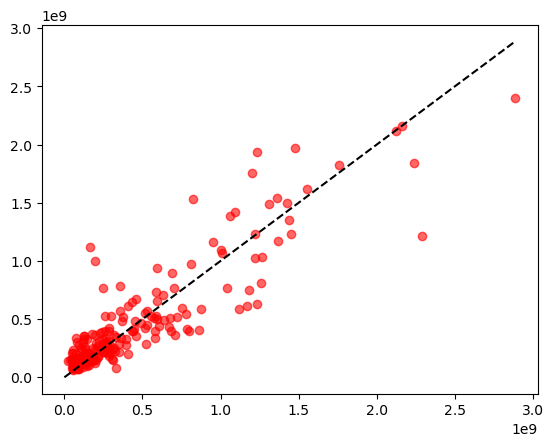

In [30]:
plt.scatter(y_test,y_pred,color='red',alpha=0.6)
plt.plot([0,max(y_test)],[0,max(y_test)],color = 'black',linestyle = '--')
plt.show()